# Monitoring Water Quality - Aquatic Weeds and floating Algae

* **Data used:** 
- Geomedians from OLI, MSI, and TM
- Surface reflectance from OLI, MSI and TM
- Water observations from space, annual summaries

## Objective
The objective of this notebook is **to provide a *practical tool* to report on the coverage of aquatic weeds (water hyacinth) and algal blooms on specific water bodies**, which can be adapted, applied and improved. 

In order to be as realistic as possible, the notebook is longer than most, and involves more data preparation steps.

## Background
A widespread phenomenon on inland waters is the presence of either photsynthesising algae - cyanobacteria, and / or aquatic weeds such as Water Hyacinth (**https://www.arc.agric.za/arc-ppri/Pages/Water-hyacinth.aspx**). These can be monitored using DE Africa data and services, and published algorithms. Water Hyacinth is particularly reported to be a problem in rift valley lakes including parts of Lake Victoria such as around the Port of Kisumu, and is a well known problem on Hartbeespoort Dam in South Africa. 

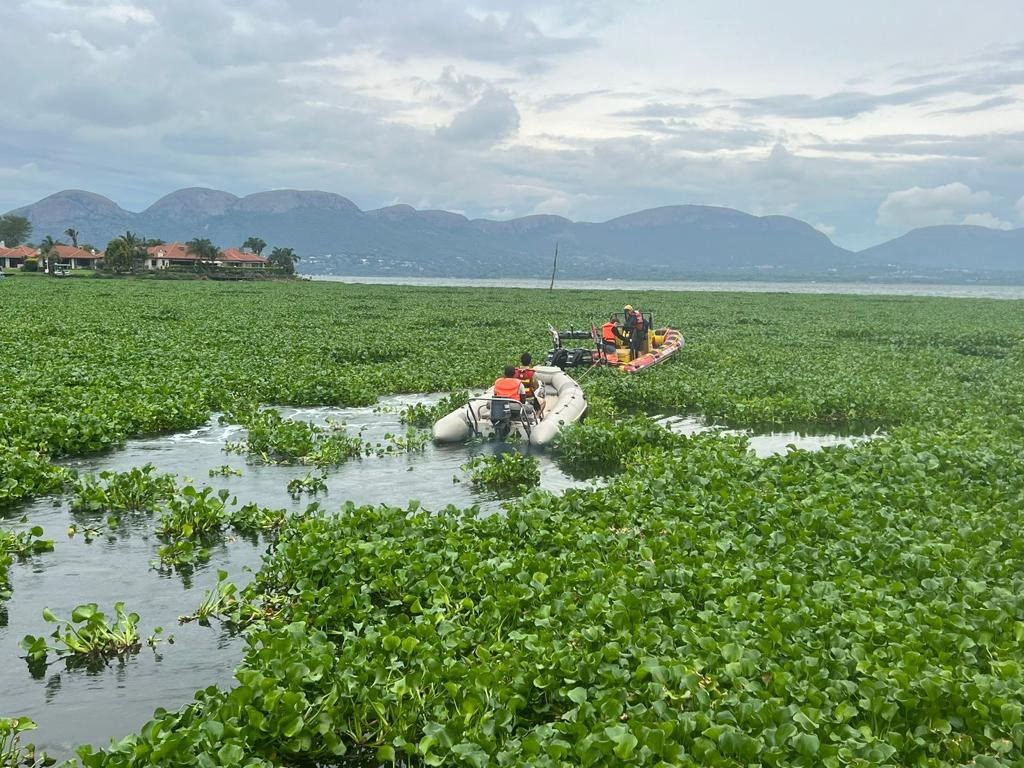
(**https://thebulrushes.com/2025/07/17/magalies-water-reduces-water-hyacinth-at-hartbeespoort-dam/**)

The **Floating Algal Index (FAI)** can be used to map and quantify the extent of these phenomena. The FAI is sensitive to photosynthetic surface material (PSM) on the water. FAI can be used with the Sentinel-MSI, Landsat-OLI and Landsat-TM instruments. Used together, the MSI and OLI sensors can provide over 100 observations each year, and the TM instrument provides continuity from the early 2000s. These observations, used in conjunction with DE Africa WOfS, Geomedians, and Waterbodies, can capture these dynamic processes and report on the percentage of area that they affect.  


### FAI
The FAI detects unexpectedly high values of near infra-red (NIR) reflectance, by comparing the NIR value reflectance with the value that would be expected given the Red, and short-wave infra-red (SWIR) reflectances. The approach takes into account the specific central wavelenghts of the sensor bands. This means that FAI is more able to support multi-sensor approaches than other measures and indices which assume identical sensor characteristics.  

The FAI is calculated by interpolating a value of the NIR band from the observed values of the Red and SWIR bands, and comparing this to the observed NIR band:

$$
InterpolatedNIR = Red + ( SWIR - Red ) * (NIR wavelength - Red wavelength)/(SWIR wavelength - Red wavelength)
$$
$$
FAI = ObservedNIR - InterpolatedNIR
$$

For the MSI sensor on the Sentinel-2 satellites, the bands (central wavelength) are listed as:
$$\text{Red wavelenth (msi band 4)} = 665   \text{ nm};  $$$$ \text{   NIR wavelenth (msi band 8a)} = 864 \text{ nm}; $$$$ \text{   SWIR wavelenth (msi band 11)} = 1612 \text{ nm}$$


Reference: **Hu, 2009, *A novel ocean color index to detect floating algae in the global oceans*** doi:10.1016/j.rse.2009.05.012

## Approach
This notebook aims to provide the foundation for a practical tool to monitor and visualise the extent of water hyacinth and cyanobacteria which produce photosynthetic material on the water surface and are often a problem. 

To do this:
1. We **choose a specific waterbody to measure**. At this time, we select a rectangle and all of the water inside of that rectangle is considered in the analysis. Further developments are anticipated to select a water polygon(s) based on the DE Africa Waterbodies service.
2. We **identify water areas for each year** using the DE Africa Water Observations from Space (WOfS). Water surfaces are constantly contracting and expanding through time. WOfS captures this variation as the frequency with which water is seen; the ''wofs_freq'' variable gives a statistical approach to defining areas of water. This allows for water often being 'hidden' beneath floating vegetation.
3. We **measure and report the area of water that is affected** using the Floating Algal Index (FAI) to identify areas of photosynthetic surface material (PSM) on the water surface.

### **Longer term patterns** (5 - 25 years) are analysed using the DE Africa geomedians
The first part of this workbook enables long-term assessment. 

For multi-year trends we apply the FAI to the DE Africa Geomedians. For any given year, DEA geomedians are produced for one or more of Landsat-TM (1990-2012), Landsat-OLI (2013-present) and Sentinel-MSI (2017-present). FAI for each year are based on all available geomedians. Geomedians capture the 'typical' state of the water during the year, so sesults from this level of analysis will detect areas and indicate years where PSM has been consistently observed during the year. 

### **Short term monitoring** (upto 3 years) calls for the source observational data
The second part of this workbook enables a more detailed analysis based on all the available surface reflectance data. This is optional, and should only be used for limited time-spans in order to stay within the memory limitations of the notebook.

For short-term monitoring we call on the full set of observations available in DE Africa from the TM, OLI and MSI sensors (this range could be increased in future). These sensors produce hundreds of observations each year. FAI for multiple sensors are compared to adjust biases, with the MSI based measurment taken as the baseline. Because aquatic weeds and algae are mobile and grow rapidly, measurements can vary rapidly day to day and week to week. This noise is smoothed with a moving average window spanning multiple observations, nominally 15. 

Analysis of hundreds of images at a time can rapdily overwhelm the memory allowance of a sandbox session. To avoid this, we down-sample the data, ensuring that we are still 'sampling' the waterbody with thousands of pixels at each time slice. 

To be confident of the results of the monitoring we compare with published material for Hartbeespoort dam in South Africa. Where results diverge we examine specific observations to confirm that the algorithms are reflecting the patterns visible in the day to day satellite images. 

### Outputs
Whilst images are used to *understand what the data are saying*, the **primary outputs** from the analyses are **statistics of affected areas**. 

### Processing steps in detail:
Several steps are involved, having chosen an area of interest:

  1. to determine actual areas of water, we access annual WOfS data for at least five years based on the time interval for analysis 
  2. we access the EO data from the data cube into two muli-sensor datasets, one **annual for geomedians**, one for **daily observations**
  3. we filter the observations on data quality, using the qa bands provided with the data
  4. we derive the FAI values for each pixel, and if necessary apply any adjustments to maximise comparability between sensor
  5. we apply a threshold on the FAI values to reteive areas of interest
  6. we calculate the proportion of the water area that is affected
  7. we produce a meaningful graph and summary report

The spatial resolution, or cell size, for the analysis is set to work within the memory limitations of the sandbox. *We can have an accurate result for a waterbody without using every pixel* 

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd     
from odc.geo.geom import Geometry


from deafrica_tools.plotting import display_map, rgb
from deafrica_tools.datahandling import load_ard, mostcommon_crs, wofs_fuser
from deafrica_tools.areaofinterest import define_area

In [2]:
import scipy as sp
from datetime import timedelta
import gc

In [51]:
from water_quality.mapping.instruments import INSTRUMENTS_MEASUREMENTS, check_instrument_dates
from water_quality.mapping.fai import FAI, geomedian_FAI, CENTRAL_WAVELENGTHS as fai_wavelengths

### Select a location
The function below stores a dictionary of places. 

You can add to this or simply select a name from the list and run the function, or use the default.

The analysis runs on the area within the coordinates.

In [4]:
# the place and times of interest can be chosen from here -- other places can be added 
def set_place_and_time(placename='Hartbeespoort_dam',year1='2024-01-01',year2='2025-10-31'):
    places = {
        'Hartbeespoort_dam':   {"xyt" :{"x": (  27.7972, 27.91117), "y" : (-25.7761,-25.7275) ,"time": (year1,year2)},"desc": "Haartbeesport Dam  -- South Africa"},
        'Lake_Manyara':        {"xyt" :{"x": ( 35.724 ,  35.929 ), "y" : ( -03.814, -03.409), "time": (year1,year2) },"desc": "Lake_Manyara, Tanzania"          },#this is the lake to use as an example of monitoring, see 2015-12-28
        'Lake_Baringo'     :   {"xyt" :{"x": (36.00,  36.17),     "y": (00.45,00.74),        "time": (year1,year2)},"desc":'Lake Baringo'    },
        'Weija_Reservoir'  :   {"xyt" :{"x": (-0.325, -0.41),     "y": ( 5.54, 5.62),        "time": (year1,year2)  },"desc":''                },
        'Lake_Sulunga'     :   {"xyt" :{"x": (34.95, 35.4),       "y": (-6.3, -5.8),         "time": (year1,year2)  },"desc":""                },
        'cameroon_res1'    :   {"xyt" :{"y": (6.20,6.30),          "x": (11.25, 11.35),      "time": (year1,year2)  },"desc": "reservoir in cameroon"},
        'Lake_vic_algae':      {"xyt" :{"x": ( 34.62, 34.78),       "y" : ( -.18,-.08),      "time": (year1,year2)  },"desc": "Lake Victoria Water Hyacinth affected area in NE, port Kisumu"},
        'Ethiopia_Lake_Tana':  {"xyt" :{"x": ( 37.05,   37.22),    "y" : (  11.9  ,  12.0),  "time": (year1,year2)  },"desc": "Ethiopia_Lake_Tana"          },
        'Mare_aux_Vacoas':     {"xyt" :{"x": ( 57.485,  57.524),   "y" : ( -20.389, -20.359),"time": (year1,year2)  },"desc": "Mare_aux_Vacoas"          },
        'SA_smalldam':         {"xyt" :{"x": ( 19.494,  19.498),   "y" : ( -33.802, -33.800),"time": (year1,year2)  },"desc": "Irrigation Dam, South Africa"          },
        'Lake Chamo'   :       {"xyt" :{"x": ( 37.45,   37.65) ,   "y" : (   5.685 ,  5.979), "time": (year1,year2)  },"desc": "Lake Chamo, Ethiopia"          },
        'Lake Ziway'   :       {"xyt" :{"x": ( 38.711,  38.966),   "y" : (   7.838 ,  8.148), "time": (year1,year2)  },"desc": "Lake Ziway, Ethiopia"          },
        'Lake Alwassa' :       {"xyt" :{"x": ( 38.380,  38.493),   "y" : (   6.977 ,  7.133), "time": (year1,year2)  },"desc": "Lake Alwassa, Ethiopia"          },
        'Lake Elmenteita' :    {"xyt" :{"x": ( 36.211,  36.273),   "y" : (  -0.488 , -0.401), "time": (year1,year2)  },"desc": "Lake Elmenteita, Kenya"          },
        'Farihy_itasy':        {"xyt" :{"x": ( 46.73 ,  46.83 ),   "y" : ( -19.10 , -19.04 ),"time": (year1,year2)},"desc": "Farihy Itasy, Madagascar"          },
        'Kolokonda':           {"xyt" :{"x": ( 35.4888, 35.5488),   "y" : ( -5.976, -5.916 ),"time": (year1,year2)},"desc": "Kolokonda, Tanzania"          },
        'Tana_Hayk'      :     {"xyt" :{"x": (  36.95 ,  37.65),   "y" : ( 11.56 , 12.33   ) ,"time": (year1,year2)},"desc": "T'ana Hayk', northern Ethiopia"},
        'Lake_Malawi'    :     {"xyt" :{"x": (  34.25 ,  34.97),   "y" : ( -13.6 , -13.3    ) ,"time": (year1,year2)},"desc": "Lake Malawi - part of"},
        'Lago de Cabora' :     {"xyt" :{"x": (  30.90 ,  32.52),   "y" : ( -15.95, -15.45  ) ,"time": (year1,year2)},"desc": "Lago de Cabora Basa - Mozambique"},
        'Mtera Reservoir':     {"xyt" :{"x": (  35.60 ,  36.01),   "y" : ( - 7.20, - 6.86  ) ,"time": (year1,year2)},"desc": "Lake Nzuhe, Tanzania"},
        'Barrage Joumine':     {"xyt" :{"x": (  09.53 ,  09.62),   "y" : ( 36.952,  37.00  ) ,"time": (year1,year2)},"desc": "Joumine Dam,Tunisia"},
        'Tunisia_Dam'    :     {"xyt" :{"x": (  08.53 ,  08.56),   "y" : ( 36.685,  36.75  ) ,"time": (year1,year2)},"desc": "Tunisia"},
        'Lake_Ngami'     :     {"xyt" :{"x": (  22.55 ,  22.89),   "y" : ( - 20.6, -20.37  ) ,"time": (year1,year2)},"desc": "Botswana"},
        'Lake_Chilwa'    :     {"xyt" :{"x": (  35.5 ,  35.9),   "y" : ( - 15.6, -14.90  ) ,"time": (year1,year2)},"desc": "Malawi - Lake Chilwa"},
        'Lake_Malombe'   :     {"xyt" :{"x": (  35.15 ,  35.35),   "y" : ( - 14.8, -14.50  ) ,"time": (year1,year2)},"desc": "Malawi - Lake Malombe"},
        'Lake_Piti'      :     {"xyt" :{"x": (  32.85 ,  32.90),   "y" : ( - 26.6, -26.50  ) ,"time": (year1,year2)},"desc": "Mozambique - Lake Piti"},
        'Maputo_reserve' :     {"xyt" :{"x": (  32.79 ,  32.83),   "y" : ( - 26.55, -26.50  ) ,"time": (year1,year2)},"desc": "Mozambique - Maputo reserve"},
        'Indian_Ocean'   :     {"xyt" :{"x": (  57.75 ,  57.80),   "y" : ( - 20.5 , -20.45  ) ,"time": (year1,year2)},"desc": "Mauritius - Oceanic waters"},
        'Mare_Vacoas'    :     {"xyt" :{"x": (  57.48 ,  57.52),   "y" : ( - 20.38 , -20.36  ) ,"time": (year1,year2)},"desc": "Mauritius - Mare aux Vacoas"},
        'Naute'          :     {"xyt" :{"x": (  17.93 ,  18.05),   "y" : ( - 26.97 , -26.92  ) ,"time": (year1,year2)},"desc": "Namibia - Naute reserve"},
        'Lake_Turkana'   :     {"xyt" :{"x": (  35.80 ,  36.72),   "y" : (    2.38 ,   4.79  ) ,"time": (year1,year2)},"desc": "Kenya -- Lake Turkana"},
        'Lake Bogoria'   :     {"xyt" :{"x": (  36.058, 36.133),   "y" : (  0.1791 ,0.3534) ,"time": (year1,year2)},"desc": "Lake Bogoria -- Tanzania"},
        }
    # --- send back the dictionary for the place of interest
    place_and_time = {}
    place_and_time['placename'] = placename
    place_and_time['xyt']       = places[placename]['xyt']
    place_and_time['desc']      = places[placename]['desc']
    return(place_and_time)

In [5]:
# here is where we actually choose the place of interest... you can also set the dates
place_and_time = set_place_and_time('Lake_Manyara',year1='2023-01-01',year2='2024-12-31')
place_and_time = set_place_and_time('Hartbeespoort_dam',year1='2023-01-01',year2='2024-12-31')


max_cells      = 10000   
# --- Max_cells is the numeber of 'samples' that we are taking for the waterbody. 

#     The default will work for 3-5 years of data on a standard sandbox. If max_cells is too big, the sandbox memory will be exceeded. 
#     Increase max_cells to visualise spatial patters of for shorter time=frames
#     Deacrease max_cells for longer time-periods.
#     To halve the pixel size, increase max_cells by 4 times. 
#     You can also set max_cells to be large if working only with the geomedians - the first part of this notebook. 

##### Set Analysis Parameters
We set the analysis parameters to work within the memory limitations of the sandbox by setting a workable grid-size. Final results are a summary of all the grid cells for the waterbody.


In [6]:
def set_analysis_parameters(place_and_time,max_cells=10000,verbose=True):
    # --- acceptable range for the cell size ---
    cell_min = 10
    cell_max = 500
    xyt      = spacetime_domain = place_and_time['xyt']
    print(xyt)
    x0,x1,y0,y1 = xyt['x'][0], xyt['x'][1], xyt['y'][0], xyt['y'][1]
    dxm = ((x1-x0) * 100000) * np.cos(y0 * np.pi/180.0) # --- metres approx allowing for lattitudinal compression of dx
    dym = ((y1-y0) * 100000)                            # --- metres approx
    dAm = abs(dxm * dym)                                # --- square metres total extent
    
    cell_dxm = ( dAm / max_cells ) ** 0.5               # --- cell size for analysis, compare with limits and convert to an integer multiple of 10
    cell_dxm = np.max([cell_dxm,cell_min])
    cell_dxm = np.min([cell_dxm,cell_max])
    cell_dxm         = int(cell_dxm / 10) * 10
    grid_resolution  = (cell_dxm,cell_dxm) 
    cellcount        = dAm / (cell_dxm**2)

    aspect_ratio = np.abs(dym/dxm)
    cell_area = (cell_dxm**2)/1000000 #km^2

    #apply a bilinear interpolation if cells that are small relative to the pixels
    if cell_dxm > 60 :
        resampling_option = "nearest"
    else:
        resampling_option = "bilinear"

        # --- extract the year from the times ---
    y1,y2 = pd.DatetimeIndex([place_and_time['xyt']['time'][0],place_and_time['xyt']['time'][1]]).year[[0,1]]

    params = {}
    params['placename'] = place_and_time['placename']
    params['xyt'], params['grid_resolution'], params['cell_area'], params['resampling_option'],params['year1'],params['year2'] = \
            xyt,grid_resolution,cell_area, resampling_option,y1,y2

    if verbose:
        print(place_and_time['placename'],' : ', place_and_time['desc'])
        print("Coordinate range       :", xyt)
        print("Years                  :", y1,y2)
        print("Grid resolution will be:", grid_resolution)
        print("Rough dimensions (x,y) : ", int(dxm/1000), " by " ,int(abs(dym/1000)), "kilometres")
        print("Total cells is roughly : ", int(cellcount))
        print("Cell area is           : ", cell_area," km2")
        print("Resampling strategy    :",resampling_option)

    return(params)
    

In [7]:
parameters = set_analysis_parameters(place_and_time,max_cells,verbose = True)

{'x': (35.724, 35.929), 'y': (-3.814, -3.409), 'time': ('2023-01-01', '2024-12-31')}
Lake_Manyara  :  Lake_Manyara, Tanzania
Coordinate range       : {'x': (35.724, 35.929), 'y': (-3.814, -3.409), 'time': ('2023-01-01', '2024-12-31')}
Years                  : 2023 2024
Grid resolution will be: (280, 280)
Rough dimensions (x,y) :  20  by  40 kilometres
Total cells is roughly :  10566
Cell area is           :  0.0784  km2
Resampling strategy    : nearest


## View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [8]:
# The code below renders a map that can be used to view the region.
display_map(place_and_time['xyt']['x'],place_and_time['xyt']['y'])

## Load annual Water Quality maps

The annual Floating Algal Index will be retrieved from the DE Africa Water Quality Monitoring Service.

In [9]:
# --- connect to the datacube ---
dc = datacube.Datacube(app="Monitoring_water_quality_FAI")

In [13]:
product = 'wq_annual'

ds_annual = dc.load(product=product,
        **place_and_time['xyt'],
        measurements = ['water_mask','agm_fai'],
        output_crs='epsg:6933',
        resolution=parameters['grid_resolution'],
        resampling=parameters['resampling_option'])

In [14]:
ds_annual

<xarray.Dataset> Size: 212kB
Dimensions:      (time: 2, y: 185, x: 71)
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-07-02T11:59:59.999999 2024-07...
  * y            (y) float64 1kB -4.862e+05 -4.859e+05 ... -4.35e+05 -4.347e+05
  * x            (x) float64 568B 3.447e+06 3.447e+06 ... 3.466e+06 3.467e+06
    spatial_ref  int32 4B 6933
Data variables:
    water_mask   (time, y, x) float32 105kB nan nan nan nan ... nan nan nan nan
    agm_fai      (time, y, x) float32 105kB nan nan nan nan ... nan nan nan nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

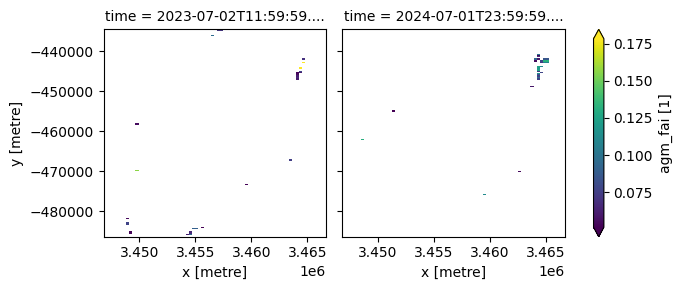

In [146]:
ds_annual.agm_fai.plot.imshow(robust=True, col='time');

#### TO DO

Add true/false colour images from geomad?


- The false-colour image will tend to highlight areas that are persistently affected by floating weed and algae.
- If algae or water weeds are prevalent the water freqency will often be below 1, even for permanent water areas.
- This is because the water is sometimes 'hidden' beneath the material on the surface. 
- **For example**, If you are looking at the default settings, you are seeing Hartbeespoort Dam. The dam wall, and therefore the deepest part of the lake, is at the northenmost point. Yet in this area the ***water frequency drops well belaw 1*** - due to persistent coverage of water hyacinth.
- **You can see these features clearly on the DE Africa map** : https://maps.digitalearth.africa/#share=s-pcg0S4isI7ZHsdvpQ0wslVswAhG).

### Annual Results:
The geomedian analysis shows the patterns of affected area on an annual basis.

It calculates the proportion of the area that was ***persistently affected*** each year, 
that is, the amount of area where high FAI values were ***"normal"*** for the year.

In [26]:
# --- run the FAI function for all pixels, 
ds_annual['fai_cover_percent'] = ((ds_annual.agm_fai.count(dim=('x','y'))  / ds_annual.water_mask.count(dim=('x','y')))*100).round(2)
ds_annual["area_km2"] = (ds_annual.water_mask.count(dim=('x','y'))*parameters['cell_area']).round(2)

In [133]:
annual_results = ds_annual[["area_km2", "fai_cover_percent"]].reset_coords("spatial_ref", drop=True).to_dataframe().reset_index()
annual_results["year"] = annual_results["time"].dt.year
annual_results

,time,area_km2,fai_cover_percent,year
0,2023-07-02 11:59:59.999999,547.00,0.49,2023
1,2024-07-01 23:59:59.999999,566.83,0.51,2024


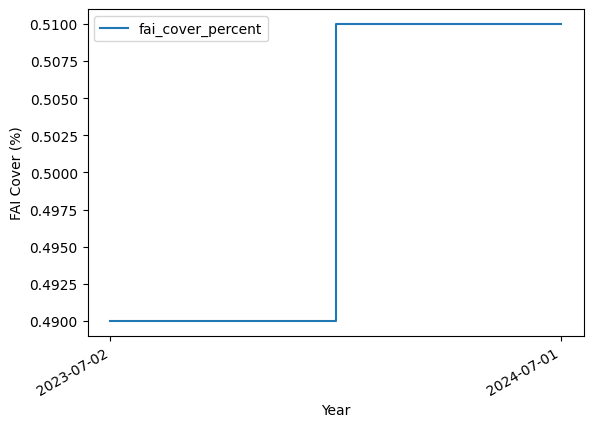

In [145]:
annual_results.plot(x="time", y="fai_cover_percent", drawstyle="steps-mid");
plt.xticks(annual_results["time"]);
plt.xlabel("Year");
plt.ylabel("FAI Cover (%)");

##### Note:
- ***area_km2*** is the area that we consider to be water, in units of square kilometers. This is calculated over a 5 year interval.
- ***fai_cover_percent*** is the percentage of the water area that was affected by algae (cyanobacteria) or floating vegetation such as water hyacinth. Since we are working from an annual median, these are the areas that were ***consistently affected***. This is therefore a conservative statistic. We can be confident that we are not over-stating the problem, or reporting on transient events.

In [28]:
#display the results from the geomedian analysis

# we want the time series data to display nicely as a step plot centred on the calendar year. This requires that we pad out the data, which is painful

#### Commentary:
- The graph shows the coverage based on all available geomedians (OLI, TM, MSI).
- Results from each geomedian appear as dotted graphs.
- The step function is used to indicate that these results are based on the entire year, not a point in time.
- When combining OLI and MSI geomedians, the number of clear observations of each pixel is used as a weight.
- The percent cover is the percentage of area that is ***normally affected*** during the year. E.g., ***In 2022, there was 30% of the lake that typically had weed cover***. We would expect this to be **less than the mean area affected**, i.e, a conservative measure.
- The geomedian results are quick to produce and indicate relative changes through time. However the *absolute values* are difficult to interpret and are sensitive to the threhold used to decide which FAI values are 'significant'. To 'calibrate' the geomedian results they need to be compared to the daily observations, which is the next part of this notebook. 

## A detailed study using *all available observations*

Working with the daily observations introduces more information, and more complexity:
- Several minutes are needed to access the data, and more memory is needed
- Datasets from each satellite / sensor must be combined to produce a single dataset

Challenges:
- Each sensor has it's own band names - we introduce **standardised variable names**, and re-name the bands, eg. ***oli01***
- We need to remember which sensor was used at each capture time - we add a boolean variable for each sensor, ***oli, msi, tm***)
- Individual images and pixels must be filtered for data quality - we add a ***qa_score*** variable, which must be greater than zero
- Some images are incomplete, covering only part of the water area - we add a ***coverage_percent*** variable to keep track of these cases 
- Results typically need to be averaged over a number of observations to smooth out the noise
- Validation - we can compare the results for Hartbeespoort dam in South Africa with published material for some years to get confidence in our results!


In [76]:
measurements = {'oli': {'SR_B4':'oli04', 'SR_B5':'oli05', 'SR_B6':'oli06', 'pq':'pq'},
                'msi': {'B04':'msi04', 'B8A':'msi8a', 'B11':'msi11', 'qa':'qa'},
                'tm': {'SR_B3':'tm03', 'SR_B4':'tm04', 'SR_B5':'tm05', 'pq':'pq'}
               }

In [77]:
for ins in products.keys():
    for k in fai_wavelengths[ins].keys():
        print(fai_wavelengths[ins][k][0])


tm03
tm04
tm05
oli04
oli05
oli06
msi04
msi8a
msi11


In [80]:
measurements = {'oli': {'red':'oli04', 'nir':'oli05', 'swir_1':'oli06', 'pixel_quality':'pq'},
                'msi': {'red':'msi04', 'nir_narrow':'msi8a', 'swir_1':'msi11', 'qa':'qa'},
                'tm': {'red':'tm03', 'nir':'tm04', 'swir_1':'tm05', 'pixel_quality':'pq'}
               }

In [81]:
products = {
    "tm": ["ls5_sr", "ls7_sr"],
    "oli": ["ls8_sr", "ls9_sr"],
    "msi": ["s2_l2a"],
}

ds_list = {}
fai_list = []
for ins in products.keys():

    #    ds_list[ins] = dc.load(product=products[ins],
    #                  **parameters['xyt'],
    #                  measurements=measurements[ins].keys(),
    #                  # mask_pixel_quality=False,
    #                  # categories_to_mask_ls={'cloud': 'high_confidence', 'cloud_shadow': 'high_confidence', 'dilated_cloud':'dilated'},
    #                  output_crs='epsg:6933',
    #                  group_by='solar_day',
    #                  resolution=parameters['grid_resolution'],
    #                  resampling=parameters['resampling_option'],
    #                  # verbose=True,
    #                  dask_chunks={},
    #                  ).rename(measurements[ins])

    ds_list[ins] = load_ard(
        dc,
        products=products[ins],
        **parameters["xyt"],
        measurements=list(measurements[ins].keys()),
        categories_to_mask_ls={
            "cloud": "high_confidence",
            "cloud_shadow": "high_confidence",
        },
        output_crs="epsg:6933",
        group_by="solar_day",
        resolution=parameters["grid_resolution"],
        resampling=parameters["resampling_option"],
        min_gooddata=0.2,  # this should be checked over water area, not at scene level
        verbose=True,
        dask_chunks={},
    ).rename(measurements[ins])

    fai_list.append(FAI(ds_list[ins], ins)) #add harmanisation before stacking

Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls5_sr
    ls7_sr
Counting good quality pixels for each time step
Filtering to 26 out of 30 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 26 time steps as a dask array
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr
    ls9_sr
Counting good quality pixels for each time step
Filtering to 132 out of 175 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 132 time steps as a dask array
Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a
Counting good quality pixels for each time step
Filtering to 81 out of 144 time steps with at least 20.0% good quality pixels
Applying pixel quality/cloud mask
Returning 81 time steps as a dask array


In [136]:
fai_threshold = 0.05

In [137]:
fai = xr.concat(fai_list, dim="time").sortby("time")

In [138]:
fai_monthly = fai.resample(time="ME").mean().compute()

In [139]:
water_mask = ds_annual.sel(time = fai_monthly.time,method='nearest').water_mask.assign_coords({'time':fai_monthly.time})

In [140]:
fai_monthly = fai_monthly.where(fai_monthly>fai_threshold).where(water_mask==1)

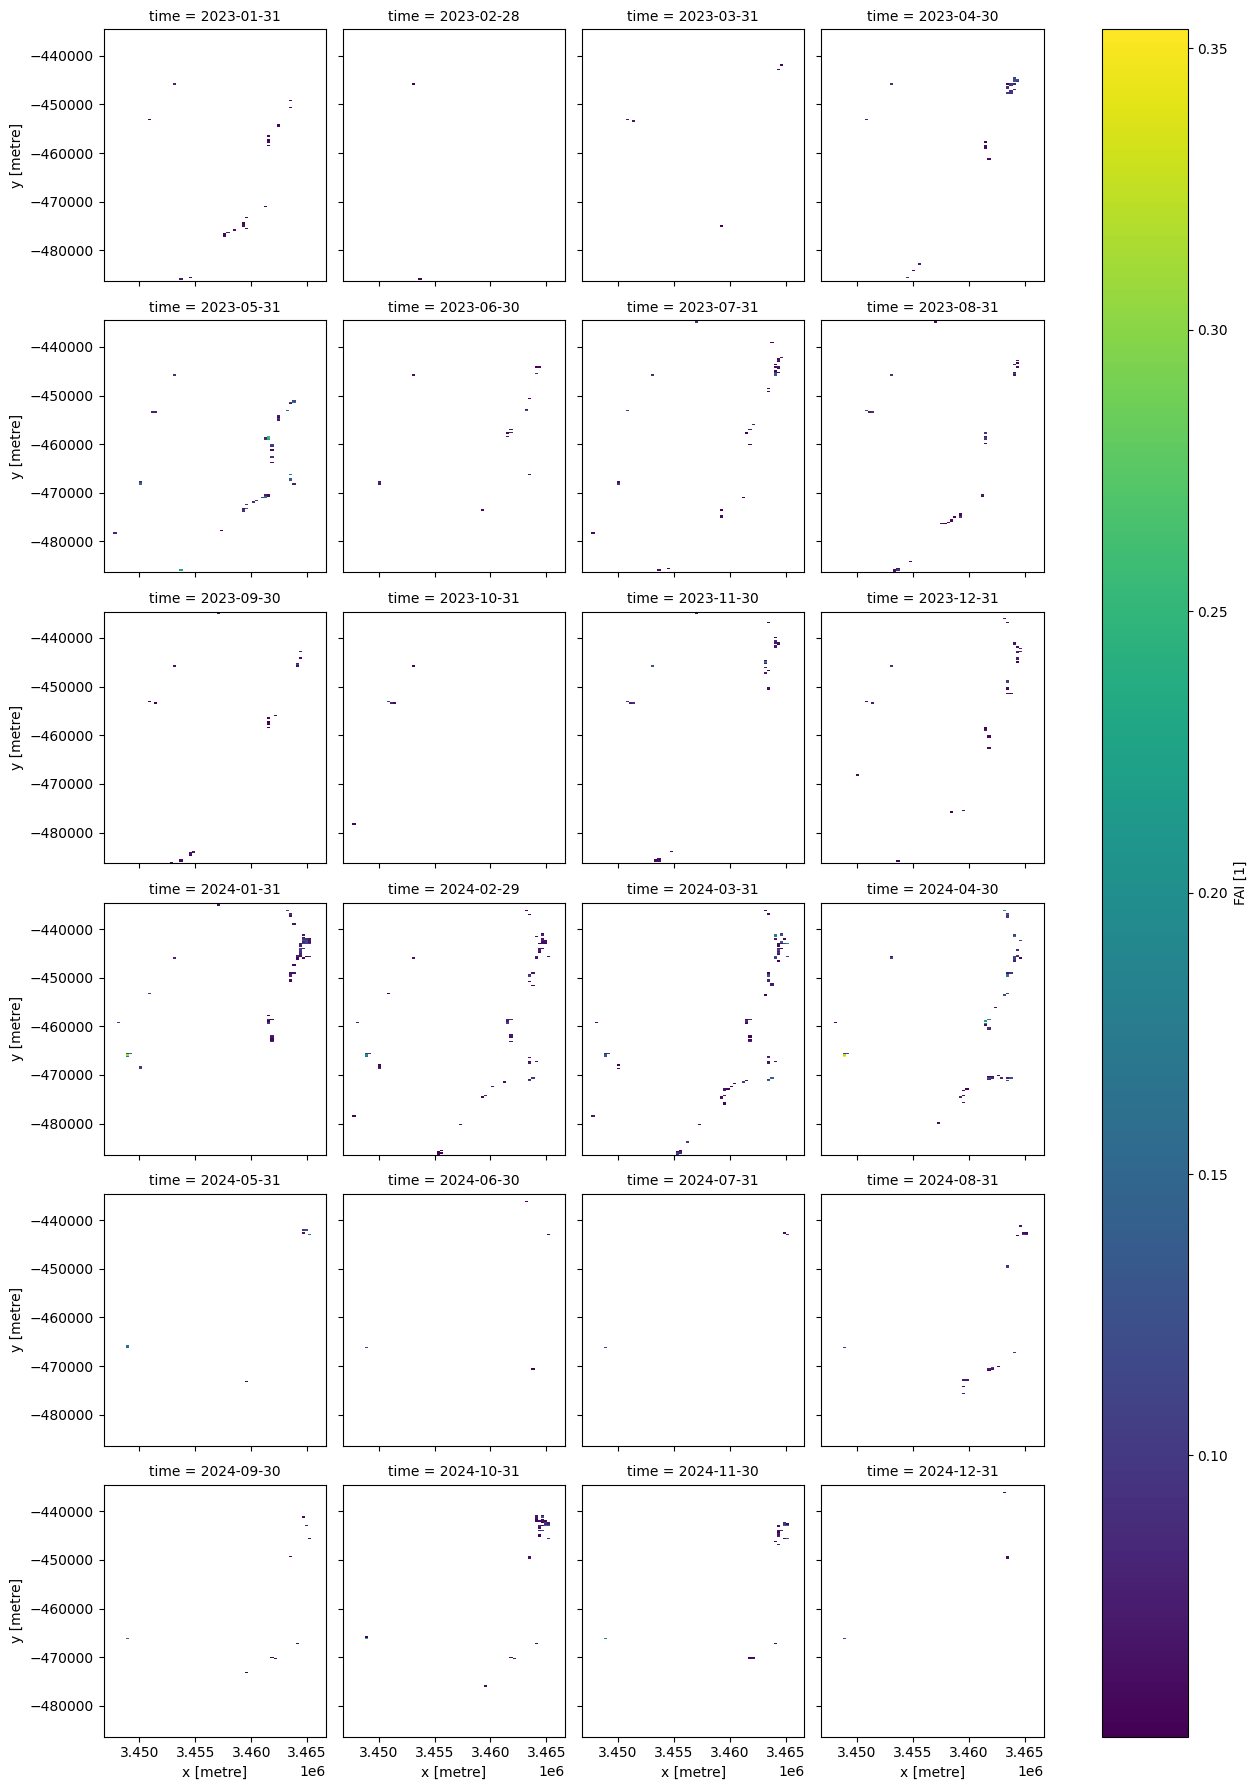

In [141]:
fai_monthly.plot.imshow(col='time', col_wrap=4);

In [142]:
fai_cover= ((fai_monthly.count(dim=('x','y'))  / water_mask.count(dim=('x','y')))*100).round(2)


In [143]:
monthly_results = fai_cover.reset_coords("spatial_ref", drop=True).to_dataframe(name='fai_cover').reset_index()

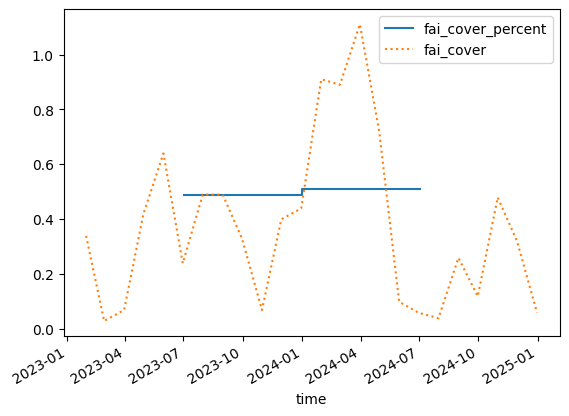

In [144]:
fig, ax = plt.subplots(1, 1)
annual_results.plot(x="time", y="fai_cover_percent", drawstyle="steps-mid", ax= ax);
monthly_results.plot(x="time", y="fai_cover", linestyle=':', ax=ax);


## TO DO

Add NDVI

Refine masking (or just double check default works fine).

Clean up descriptions

#### Apply a water mask and determine the coverage and quality of each image
- We choose the water mask for the year at the core of the time series

#### Drop dates (i.e. images) for dates when the coverage of good data is low
- images that are more than mostly cloudy are less useful when producing average statistics for the waterbody.
- dropping pood quality dates reduces the size of the dataset

#### Calculate the per-pixel FAI and apply a threshold
- we already have an FAI function that we can use for this, however there is some housekeeping to do

### Calculate the percentage cover
- divide the number of pixels where the FAI is high (above a threshold of 0.1), by the water area.
- we have to also allow for missing data, such as gaps in ETM data, or cloud cover.

The threshold of 0.1 is conservative; FAI over this are very unlikely to be 'noise'. 
- with a conservative threshold, we can be confident that we are **not over-estimating** the affected area.
- results are not very sensitive to the threshold; values between 0.05 and 0.1 will give similar results.

As well as cloud affecting the imagery,floating weeds and algae can move and change rapidly. We can smooth the data over several observations to better reveal systematic changes.

### Results
- As well as the overall results, **we can check at this point that we are not seeing differences between sensors**. If differences were apparent, we would want to adjust one sensor to match the others.
  
- With the default settings - Hartbeespoort dam in South Africa - you may see that on 2024-01-04 both landsat (oli) and sentinel-2 (msi) captured data. Both instruments produced an estimated coverage of 31% at that time. This gives some confidence that the methods are working!

  
- A second approach to validating the results is to examine images of specific dates in the DE Africa map:
   **For the default setting of Hartbeespoort Dam this link shows the coverage at 2025-10-15:** https://maps.digitalearth.africa/#share=s-aGgNgwMuNyV1XIj5ja69I5jVyW9

  
- Examining the map also shows that during high coverage periods there is also often high cloud, leading to higher variance in the estimated areas (since we estimate the percentage coverage based on the area that we can see). This produces scatter in the graph.

- Finally, results can also be compared with published data on this dam - **see following panel** 
  
We should also compare the 'daily' results with the results from the annual geomedian analysis. 
- The Geomedian indicates the percentage of area that was **consistently affected throughout the year** and is a conservative statistic.
- We expect it to be less than the mean coverage, but in the same ball-park.
- The geomedian values **will indicate *year on year changes in severity***, but will be less reliable pre-2013.

### Comparison with external results
The graph below compares findings from these methods with results published by rosali.moffat@fabi.up.ac.za, https://www.sciencedirect.com/science/article/pii/S1049964424001099.

The results are very consistent some areas, however we detect material at times (in 2021 and 2022) when the authors report low coverage. 
- Examination of imagery on the DE Africa map confirms that photsynthetic material was certaily present at these times, e.g.:
 **2022-09-06, which you can see here**: https://maps.digitalearth.africa/#share=s-dXe6dhdEBnp6IDQoOsUFKkIVXIJ

The most likely explanation for this is that the authors went one step further, to separate *algal blooms* from water hyacinth. In this workbook **we do NOT separate out floating algae from vegetation** - both give a high FAI. 

Importantly, **the magnitude of the coverage is consistent**, giving us confidence that our methods are effective and accurate. 


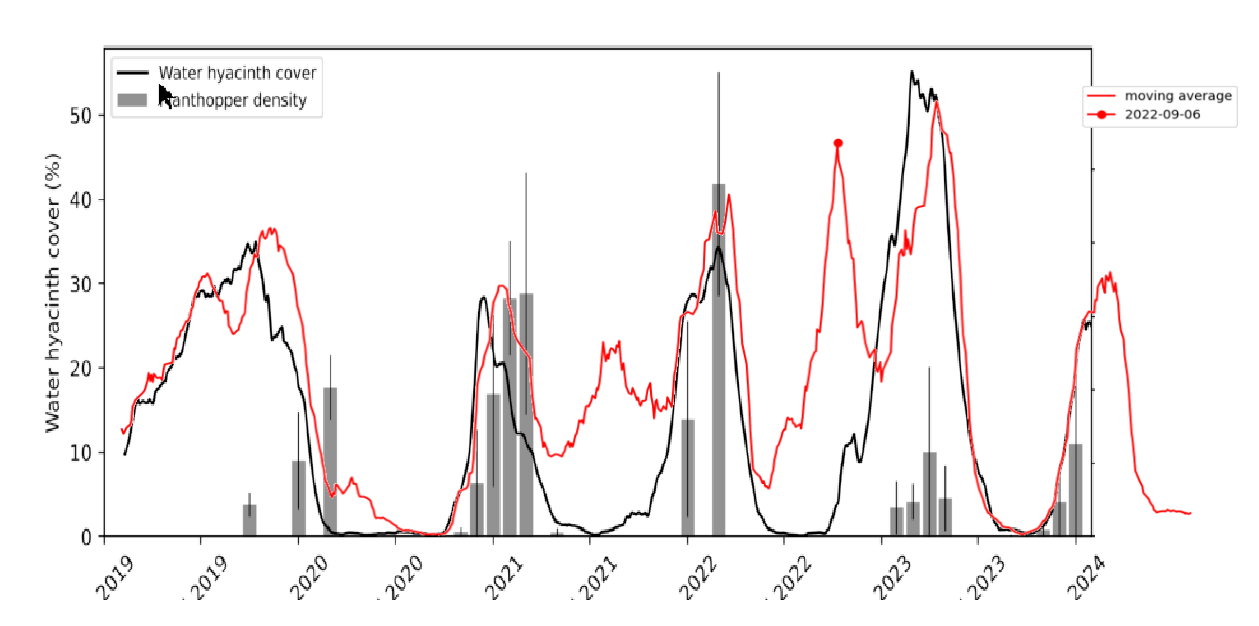

### Export results to a file
At this point, we can save all the remaining results to text and csv files!

---

## Additional information

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

<b> Compatible datacube version </b>

In [ ]:
print(datacube.__version__)

**Last Tested:**

In [ ]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')